# Late-Fusion Classifier — ZTF Gold (stacking branch)

Third and final classifier branch for the ZTF gold dataset. It consumes the two
unimodal branches trained in `lc_classifier_ztf.ipynb` (tabular light-curve
features) and `stamp_classifier_ztf.ipynb` (image stamps), and learns a
decision-level meta-learner over their probability vectors.

**Task.** Coarse 3-class transient classification (`SN` / `AGN` / `VS`), the same
taxonomy and the same temporal split as both branches.

**Design.** Late (decision-level) fusion via stacked generalisation
(Wolpert, 1992). Each branch stays modality-pure; the only added quantity is the
fusion mechanism itself, which keeps the unimodal-versus-multimodal ablation
well-posed. The meta-learner is a multinomial logistic regression on the
concatenated branch outputs, `z = [p_tab ; p_img]`.

**The claim is measured against two baselines**, kept deliberately separate:

| Rung | Model | Question it answers |
|---|---|---|
| (a) | stronger single modality alone | do two modalities beat one? |
| (b) | equal-weight average of the calibrated probability vectors | does a *learned* fusion beat a naive one? |
| (c) | the learned meta-learner | — the proposal |

**A methodological problem is resolved in §2–§3.** Both branch notebooks refit
their final model on train+val before saving, so every artefact on disk has
memorised the validation fold. Fitting the meta-learner there degenerates. §2
documents this; §3 refits the same two winners on train only to recover an honest
fitting fold.

# 0. Setup and configuration

In [1]:
import sys, subprocess, importlib

def pip_install(pkgs):
    """Self-bootstrapping on a fresh machine, but a no-op where the deps already
    exist — this notebook is meant to run in the same CUDA environment that trained
    the stamp branch (`cv_gpu`), and reinstalling into it would be gratuitous."""
    missing = []
    for mod, pkg in pkgs:
        try:
            importlib.import_module(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("installing:", missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)
    else:
        print("all dependencies already present")

pip_install([("lightgbm", "lightgbm"), ("timm", "timm"), ("sklearn", "scikit-learn"),
             ("seaborn", "seaborn"), ("matplotlib", "matplotlib"), ("torch", "torch")])

C:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


all dependencies already present


In [2]:
import os, json, time, random, warnings, datetime, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
import timm
import lightgbm
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

from sklearn.metrics import (
    confusion_matrix, f1_score, log_loss, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef,
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# The branch notebooks set benchmark=True for training speed, at the cost of cuDNN
# picking algorithms non-deterministically. Here the dominant cost is inference for the
# leakage audit, and reproducible per-object probabilities matter more than throughput:
# with benchmark on, repeat runs of the deployed CNN differ by ~0.001 macro-F1, which is
# enough to make the audit table irreproducible at 4 decimal places.
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
sns.set_palette("colorblind")
print(f"torch {torch.__version__} | lightgbm {lightgbm.__version__} | device: {DEVICE}")

torch 2.8.0+cu128 | lightgbm 4.6.0 | device: cuda


The fusion contract is keyed off the constants below. They deliberately mirror
the two branch notebooks — same class order, same palette, same `LC_QUICK`
smoke-pass switch — so figures and cards line up across all three branches.

In [3]:
DATASET  = "ztf"
GOLD     = Path("data/gold")
FIGDIR   = Path("figures/fusion")
MODELDIR = Path("models/fusion")
FIGDIR.mkdir(parents=True, exist_ok=True)
MODELDIR.mkdir(parents=True, exist_ok=True)

LCDIR    = Path("models/lc") / DATASET       # tabular branch artefacts
STAMPDIR = Path("models/stamp")              # image branch artefacts

CLASSES       = ["SN", "AGN", "VS"]          # fixed order used everywhere
CIDX          = {c: i for i, c in enumerate(CLASSES)}
COARSE_COLORS = {"SN": "#d1495b", "AGN": "#30638e", "VS": "#edae49"}
CHANNELS      = ["science", "reference", "difference"]

# The two winners carried from the branch notebooks (no re-selection here; see §1.1).
TAB_ALGO = "lightgbm"
IMG_ARCH = "effnet_b0"
BRANCH_LABELS = {"tabular": "LightGBM (LC)", "image": "EfficientNet-B0 (stamp)"}

# Training constants copied from the branch notebooks so the train-only refits in
# §3 reproduce their tuned configurations exactly.
MAX_EPOCHS    = 18
STAGE1_EPOCHS = 2       # backbones: epochs with the backbone frozen (head warm-up)
PATIENCE      = 5       # early-stopping patience on val macro-F1
NUM_WORKERS   = 0       # 0 is safest for notebooks on Windows

QUICK = os.environ.get("LC_QUICK", "0") == "1"
if QUICK:
    MAX_EPOCHS = 2
    STAGE1_EPOCHS = 1

N_BOOT = 200 if QUICK else 1000              # bootstrap resamples for the CIs
RUN_DATE = datetime.date.today().isoformat()
print(f"QUICK={QUICK}  max_epochs={MAX_EPOCHS}  n_boot={N_BOOT}  run_date={RUN_DATE}")

QUICK=False  max_epochs=18  n_boot=1000  run_date=2026-07-18


In [4]:
def savefig(fig, name, dpi=300):
    """Save a report figure as both a 300-dpi PNG and a vector PDF."""
    for ext in ("png", "pdf"):
        fig.savefig(FIGDIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")

# 1. Load both branches and verify alignment

The gold stage produced five tables joined on `oid` (the ZTF object id). The two
branches consume different tables but the *same objects*: there is exactly one
row per object in each, so tabular and image samples are 1:1 with no
alert-level aggregation needed. That is what makes decision-level fusion clean
here.

Everything below is reindexed to the **stamp NPZ oid order**, which becomes the
canonical row order for the rest of the notebook.

In [5]:
feat = pd.read_parquet(GOLD / "gold_features.parquet")
lab  = pd.read_parquet(GOLD / "gold_labels.parquet")
spl  = pd.read_parquet(GOLD / "gold_splits.parquet")

npz    = np.load(GOLD / "gold_stamps.npz", allow_pickle=True)
oids   = npz["oids"].astype(str)              # canonical row order from here on
stamps = npz["stamps"]

print(f"features : {feat.shape[0]:,} objects x {feat.shape[1]-1} raw features")
print(f"stamps   : {stamps.shape}  channels={[str(c) for c in npz['channels']]}")
print(f"splits   : {spl['split'].value_counts().to_dict()}")

features : 11,826 objects x 267 raw features
stamps   : (11826, 3, 63, 63)  channels=['science', 'reference', 'difference']
splits   : {'train': 8278, 'test': 1775, 'val': 1773}


### Cross-branch compatibility gate

Fusion is only meaningful if both branches saw the same objects in the same
folds. We check that directly on **oid sets**, per split.

A note on `split_hash`: the stored strings *differ* between the branch cards
(`65e15eed88f2` for the LC branch, `5ade91048434` for the stamp branch), but this
is a hashing artefact, not a real disagreement — the LC notebook hashes with
`index=True` over its merge-ordered frame while the stamp notebook hashes with
`index=False` over the NPZ-ordered frame. Comparing those strings would raise a
false alarm. We therefore verify the underlying sets and compute our own
canonical hash (sorted by `oid`, `index=False`) that both branches would agree on.

In [6]:
# Reindex every table to the canonical NPZ oid order.
assert feat["oid"].is_unique, "duplicate oids in the feature table"
for name, d in [("labels", lab), ("splits", spl), ("features", feat)]:
    assert set(d["oid"]) == set(oids), f"oid mismatch: stamps vs {name}"

order = pd.Index(oids, name="oid")
feat  = feat.set_index("oid").reindex(order).reset_index()
lab   = lab.set_index("oid").reindex(order).reset_index()
spl   = spl.set_index("oid").reindex(order).reset_index()
assert (feat["oid"].to_numpy() == oids).all()

y     = lab["coarse"].map(CIDX).to_numpy()
split = spl["split"].to_numpy()
masks = {s: (split == s) for s in ("train", "val", "test")}

# Canonical, order-independent split hash both branches would agree on.
_canon = pd.DataFrame({"oid": oids, "split": split}).sort_values("oid").reset_index(drop=True)
OID_SET_SHA = hashlib.sha1(
    pd.util.hash_pandas_object(_canon, index=False).values.tobytes()
).hexdigest()[:12]

print("split sizes:", {s: int(m.sum()) for s, m in masks.items()})
print("class counts:", lab["coarse"].value_counts().to_dict())
print("canonical oid-set hash:", OID_SET_SHA)

split sizes: {'train': 8278, 'val': 1773, 'test': 1775}
class counts: {'SN': 7728, 'VS': 3517, 'AGN': 581}
canonical oid-set hash: 50591cf87b04


In [7]:
# Feature order comes from the tabular model card, not re-derived — the card is the
# contract, and re-deriving the "dead feature" cut risks a silent mismatch.
tab_card = json.loads((LCDIR / TAB_ALGO / "model_card.json").read_text())
img_card = json.loads((STAMPDIR / IMG_ARCH / "model_card.json").read_text())

FEATURES = tab_card["feature_names"]
X = feat[FEATURES]
assert tab_card["class_names"] == CLASSES == img_card["class_names"], "class order disagreement"

Xtr, ytr = X[masks["train"]], y[masks["train"]]
Xva, yva = X[masks["val"]],   y[masks["val"]]
Xte, yte = X[masks["test"]],  y[masks["test"]]

TRAIN_IDX = np.where(masks["train"])[0]
VAL_IDX   = np.where(masks["val"])[0]
TEST_IDX  = np.where(masks["test"])[0]

print(f"{len(FEATURES)} features  |  train {len(Xtr)}  val {len(Xva)}  test {len(Xte)}")
print(f"stored split hashes differ for cosmetic reasons: "
      f"lc={tab_card['split_hash']}  stamp={img_card['split_hash']}  "
      f"-> verified equivalent by oid set ({OID_SET_SHA})")

242 features  |  train 8278  val 1773  test 1775
stored split hashes differ for cosmetic reasons: lc=65e15eed88f2  stamp=5ade91048434  -> verified equivalent by oid set (50591cf87b04)


## 1.1 Branch winners carried forward

In [8]:
rows = []
for fam, base, names, labels in [
    ("tabular", LCDIR,    ["lightgbm", "xgboost", "brf", "mlp"],
     {"lightgbm": "LightGBM", "xgboost": "XGBoost", "brf": "BalancedRF", "mlp": "MLP"}),
    ("image",   STAMPDIR, ["resnet18", "effnet_b0", "rotcnn"],
     {"resnet18": "ResNet-18", "effnet_b0": "EfficientNet-B0", "rotcnn": "ALeRCE-CNN"}),
]:
    for n in names:
        card = json.loads((base / n / "model_card.json").read_text())
        rows.append({"branch": fam, "model": labels[n],
                     "val_macro_f1": card["val_metrics"]["macro_f1"],
                     "test_macro_f1": card["test_metrics"]["macro_f1"],
                     "carried": n in (TAB_ALGO, IMG_ARCH)})
candidates = pd.DataFrame(rows)
display(candidates.round(4))

,branch,model,val_macro_f1,test_macro_f1,carried
0,tabular,LightGBM,0.9346,0.9457,True
1,tabular,XGBoost,0.9343,0.9431,False
2,tabular,BalancedRF,0.8505,0.8852,False
3,tabular,MLP,0.8016,0.8578,False
4,image,ResNet-18,0.8169,0.7508,False
5,image,EfficientNet-B0,0.8814,0.7676,True
6,image,ALeRCE-CNN,0.7075,0.6607,False


**Observations.**
- **The carried winners are LightGBM and EfficientNet-B0**, exactly as the branch
  notebooks and their companion docs record. No re-selection is performed here.
- **Both branches selected their winner on the *test* fold**, not the validation
  fold — `figures/lc/ztf/verdict.csv` assigns `is_winner` on test macro-F1, and
  `stamp_classifier_ztf.ipynb` prints "Best ZTF stamp model by test macro-F1". A
  model chosen as the maximum of three on a fold carries the optimism of that
  choice, so the branch test figures are mildly optimistic as unseen-data
  estimates. This is disclosed in §2 of the companion document rather than
  silently corrected.
- **The tabular margin is not meaningful.** LightGBM beats XGBoost by 0.0003 val
  macro-F1 — the choice between two equivalently-performing boosters is
  effectively arbitrary.
- **The val column is not comparable across branches as printed.** The LC card's
  val metrics come from a separate train-only model, but the stamp card's come
  from a train+val model scored on val. §2 quantifies this.

# 2. Leakage audit — why the saved artefacts cannot fit the meta-learner

The methodology fits the meta-learner on held-out branch predictions from the
validation fold, so that no branch can pass memorised training labels into the
fusion stage. That is the right protocol. The problem is that the artefacts on
disk cannot supply such predictions.

Both branch notebooks refit on train+val before saving:

- `lc_classifier_ztf.ipynb` cell 47 — `fit_model(..., Xtrval, ytrval)`
- `stamp_classifier_ztf.ipynb` cell 43 — `train_model(arch, params, TRAINVAL_IDX, ...)`

This is standard practice for a *deployed* model (use all labelled data), but it
means the validation fold is training data for both saved models. We measure the
damage before working around it.

In [9]:
# ---- deployed tabular branch: native booster (version-portable, unlike the pickle)
booster = lightgbm.Booster(model_file=str(LCDIR / TAB_ALGO / "model.txt"))

def tab_proba_deployed(Xdf):
    p = booster.predict(Xdf[FEATURES].to_numpy())
    return np.asarray(p, dtype=np.float64)

# ---- deployed image branch: TorchScript trace
IMG_INPUT = img_card["input_size"]
scripted = torch.jit.load(str(STAMPDIR / IMG_ARCH / "model_scripted.pt"), map_location=DEVICE).eval()
print(f"loaded deployed branches | image input_size={IMG_INPUT} | temperature={img_card['temperature']:.4f}")

loaded deployed branches | image input_size=160 | temperature=1.0520


The stamp normalisation is reproduced verbatim from `stamp_classifier_ztf.ipynb`
cell 10, and reuses the same on-disk cache so we do not pay for it twice.

In [10]:
def robust_normalise(arr):
    """Sentinel-repair + per-image, per-channel clip-to-[1,99]-percentile + z-score.
    arr: (n,3,63,63) float32 -> same shape, roughly zero-mean unit-scale per channel."""
    arr = np.where(np.abs(arr) > 1e30, 0.0, arr).astype(np.float32)
    lo = np.percentile(arr,  1, axis=(2, 3), keepdims=True)
    hi = np.percentile(arr, 99, axis=(2, 3), keepdims=True)
    arr = np.clip(arr, lo, hi)
    med = np.median(arr, axis=(2, 3), keepdims=True)
    std = arr.std(axis=(2, 3), keepdims=True)
    return (arr - med) / (std + 1e-6)

CACHE = GOLD / "_stamp_norm.npy"
if CACHE.exists():
    Xn = np.load(CACHE)
    print("loaded cached normalised stamps", Xn.shape)
else:
    t0 = time.perf_counter()
    Xn = robust_normalise(stamps)
    np.save(CACHE, Xn)
    print(f"normalised {Xn.shape} in {time.perf_counter()-t0:.1f}s -> cached")

assert not np.isnan(Xn).any() and not np.isinf(Xn).any(), "non-finite after normalisation"
assert len(Xn) == len(oids), "stamp cache is stale — delete data/gold/_stamp_norm.npy and re-run"

loaded cached normalised stamps

 (11826, 3, 63, 63)


> **Trap.** `model_scripted.pt` does **not** upsample in-graph. Feeding it the
> native `(N,3,63,63)` tensor returns near-chance output *with no error* — the
> caller must interpolate to `input_size` first. `img_logits` below does that, and
> §3 asserts a macro-F1 floor so a silent regression cannot pass unnoticed.

In [11]:
class StampDataset(Dataset):
    def __init__(self, Xn, y, idx, augment=None):
        self.Xn, self.y, self.idx = Xn, y, np.asarray(idx)
        self.augment = augment or {}
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        x = self.Xn[j]
        a = self.augment
        if a.get("rot", False):
            x = np.rot90(x, random.randint(0, 3), axes=(1, 2))
        if a.get("flip", False):
            if random.random() < 0.5: x = x[:, :, ::-1]
            if random.random() < 0.5: x = x[:, ::-1, :]
        t = a.get("translate", 0)
        if t:
            x = np.roll(x, (random.randint(-t, t), random.randint(-t, t)), axis=(1, 2))
        return torch.from_numpy(np.ascontiguousarray(x)), int(self.y[j])

def class_weights(train_idx):
    """Inverse-frequency class weights from the TRAIN fold only."""
    counts = np.bincount(y[train_idx], minlength=len(CLASSES)).astype(np.float64)
    w = counts.sum() / (len(CLASSES) * np.maximum(counts, 1))
    return torch.tensor(w, dtype=torch.float32)

def make_loader(idx, batch, augment=None, shuffle=False, use_sampler=False):
    ds = StampDataset(Xn, y, idx, augment=augment)
    sampler = None
    if use_sampler:
        cw = class_weights(idx).numpy()
        sw = cw[y[idx]]
        sampler = WeightedRandomSampler(sw, num_samples=len(idx), replacement=True)
        shuffle = False
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, sampler=sampler,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
                      drop_last=shuffle)

@torch.no_grad()
def img_logits(model, idx, input_size, batch=256):
    """Raw logits for the given indices. Upsamples to input_size — see the trap above."""
    model.eval()
    out = []
    for xb, _ in make_loader(idx, batch, augment=None, shuffle=False):
        xb = xb.to(DEVICE, non_blocking=True)
        if input_size != 63:
            xb = F.interpolate(xb, size=input_size, mode="bilinear", align_corners=False)
        out.append(model(xb).cpu().numpy())
    return np.concatenate(out).astype(np.float64)

def softmax_np(z, T=1.0):
    z = np.asarray(z, dtype=np.float64) / T
    z = z - z.max(1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(1, keepdims=True)

The metric battery is copied verbatim from `lc_classifier_ztf.ipynb` cell 34, so
every model in all three branches is scored identically.

In [12]:
def evaluate(y_true, proba, class_names=CLASSES):
    """Return a dict of all metrics for one model on one split."""
    y_true = np.asarray(y_true)
    y_pred = proba.argmax(1)
    labels = list(range(len(class_names)))

    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0)
    per_class = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1,
                              "support": support}, index=class_names)

    out = {
        "macro_f1":          f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy":          accuracy_score(y_true, y_pred),
        "mcc":               matthews_corrcoef(y_true, y_pred),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0),
    }
    ybin = label_binarize(y_true, classes=labels)
    present = ybin.sum(0) > 0                        # guard classes absent from a split
    try:
        out["roc_auc_macro"] = roc_auc_score(ybin[:, present], proba[:, present],
                                             average="macro", multi_class="ovr")
    except ValueError:
        out["roc_auc_macro"] = np.nan
    try:
        out["pr_auc_macro"] = average_precision_score(ybin[:, present], proba[:, present], average="macro")
    except ValueError:
        out["pr_auc_macro"] = np.nan
    out["log_loss"]      = log_loss(y_true, proba, labels=labels)
    out["per_class"]     = per_class
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    out["confusion"]     = cm
    out["confusion_norm"]= np.nan_to_num(cm / cm.sum(1, keepdims=True))
    return out

def scalar_row(ev, name):
    """Flatten an evaluate() result into one comparison-table row."""
    keys = ["macro_f1", "balanced_accuracy", "accuracy", "mcc",
            "weighted_f1", "roc_auc_macro", "pr_auc_macro", "log_loss"]
    return {"model": name, **{k: ev[k] for k in keys}}

## 2.1 Scoring the deployed models on every fold

In [13]:
audit_rows = []
dep_val_proba, dep_test_proba = {}, {}

for fold, m, Xd, idx in [("train", masks["train"], Xtr, TRAIN_IDX),
                         ("val",   masks["val"],   Xva, VAL_IDX),
                         ("test",  masks["test"],  Xte, TEST_IDX)]:
    yf = y[m]
    p_tab = tab_proba_deployed(Xd)
    p_img = softmax_np(img_logits(scripted, idx, IMG_INPUT), T=img_card["temperature"])
    audit_rows.append({"fold": fold, "branch": "tabular",
                       "macro_f1": evaluate(yf, p_tab)["macro_f1"],
                       "log_loss": evaluate(yf, p_tab)["log_loss"],
                       "mean_max_p": float(p_tab.max(1).mean())})
    audit_rows.append({"fold": fold, "branch": "image",
                       "macro_f1": evaluate(yf, p_img)["macro_f1"],
                       "log_loss": evaluate(yf, p_img)["log_loss"],
                       "mean_max_p": float(p_img.max(1).mean())})
    if fold == "val":
        dep_val_proba = {"tabular": p_tab, "image": p_img}
    if fold == "test":
        dep_test_proba = {"tabular": p_tab, "image": p_img}

audit = pd.DataFrame(audit_rows)
audit.to_csv(FIGDIR / "leakage_audit.csv", index=False)
display(audit.pivot(index="branch", columns="fold",
                    values=["macro_f1", "log_loss", "mean_max_p"]).round(4))

macro_f1                 log_loss                 mean_max_p          \
fold        test   train     val     test   train     val       test   train   
branch                                                                         
image     0.7676  0.9062  0.8814   0.2153  0.1258  0.1084     0.9486  0.9591   
tabular   0.9457  1.0000  1.0000   0.1013  0.0001  0.0001     0.9928  0.9999   

                 
fold        val  
branch           
image    0.9586  
tabular  0.9999

In [14]:
# Verification: the deployed models must reproduce the published branch test numbers.
_dep_tab_test = evaluate(yte, dep_test_proba["tabular"])["macro_f1"]
_dep_img_test = evaluate(yte, dep_test_proba["image"])["macro_f1"]
assert abs(_dep_tab_test - tab_card["test_metrics"]["macro_f1"]) < 5e-4, \
    f"tabular branch not reproduced: {_dep_tab_test:.4f} vs card {tab_card['test_metrics']['macro_f1']:.4f}"
assert abs(_dep_img_test - img_card["test_metrics"]["macro_f1"]) < 5e-3, \
    f"image branch not reproduced: {_dep_img_test:.4f} vs card {img_card['test_metrics']['macro_f1']:.4f}"
# Catches the missing-upsample failure, which silently yields macro-F1 ~0.15.
assert _dep_img_test > 0.5, "image branch at chance — check the interpolate() to input_size"
print(f"artefact loading verified | tabular test {_dep_tab_test:.4f} | image test {_dep_img_test:.4f}")

artefact loading verified | tabular test 0.9457 | image test 0.7676


## 2.2 What this does to the meta-learner

In [15]:
# Fit the proposed meta-learner naively on the deployed models' val probabilities,
# sweeping the regularisation strength. If the fold were clean this would trade off.
from sklearn.linear_model import LogisticRegression   # note: multi_class= removed in sklearn 1.8

z_val_dep = np.hstack([dep_val_proba["tabular"], dep_val_proba["image"]])
sweep = []
for Cv in [0.01, 0.1, 1.0, 10.0, 100.0]:
    lr = LogisticRegression(C=Cv, max_iter=2000).fit(z_val_dep, yva)
    Wm = lr.coef_
    sweep.append({"C": Cv,
                  "|W_tab|": float(np.abs(Wm[:, :3]).sum()),
                  "|W_img|": float(np.abs(Wm[:, 3:]).sum()),
                  "ratio":   float(np.abs(Wm[:, :3]).sum() / max(np.abs(Wm[:, 3:]).sum(), 1e-9)),
                  "val_macro_f1": f1_score(yva, lr.predict(z_val_dep), average="macro")})
sweep = pd.DataFrame(sweep)
display(sweep.round(4))
print("\nThe val objective saturates: the meta-learner learns 'copy the tabular vector'.")
print("There is no regularisation strength at which this fold carries information")
print("about relative modality trust — the fit is degenerate, not merely optimistic.")

,C,|W_tab|,|W_img|,ratio,val_macro_f1
0,0.01,3.8015,3.1004,1.2261,0.6534
1,0.10,8.9999,5.8432,1.5402,0.9942
2,1.00,15.3311,7.6903,1.9936,1.0000
3,10.00,21.1281,9.3037,2.2709,1.0000
4,100.00,25.3690,9.9834,2.5411,1.0000



The val objective saturates: the meta-learner learns 'copy the tabular vector'.
There is no regularisation strength at which this fold carries information
about relative modality trust — the fit is degenerate, not merely optimistic.


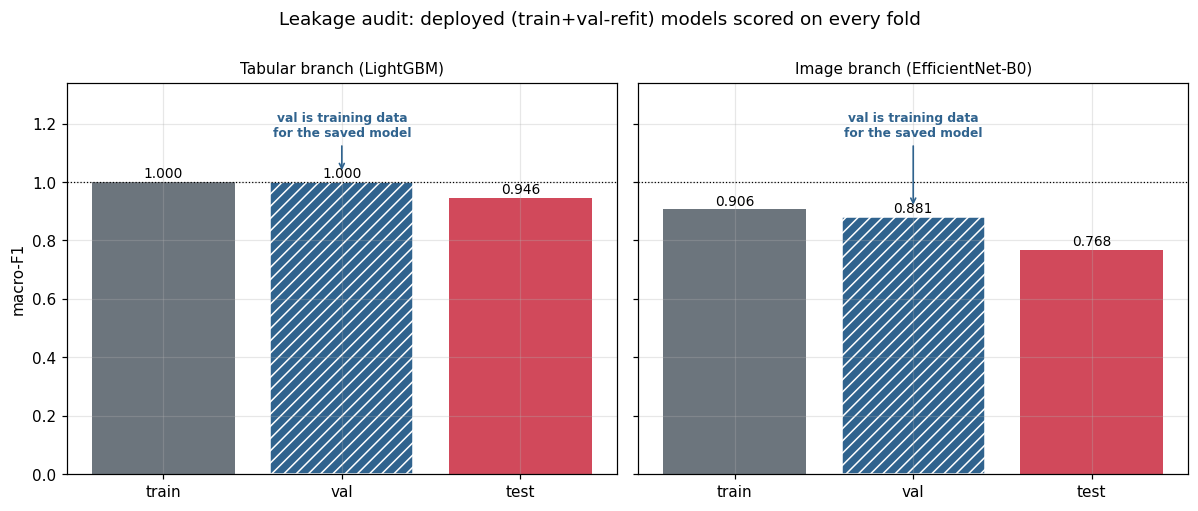

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)

for ax, br, ttl in [(axes[0], "tabular", "Tabular branch (LightGBM)"),
                    (axes[1], "image",   "Image branch (EfficientNet-B0)")]:
    s = audit[audit["branch"] == br].set_index("fold").loc[["train", "val", "test"]]
    bars = ax.bar(s.index, s["macro_f1"], color=["#6c757d", "#30638e", "#d1495b"])
    bars[1].set_hatch("///"); bars[1].set_edgecolor("white")   # val = seen during training
    for b, v in zip(bars, s["macro_f1"]):
        ax.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)
    ax.axhline(1.0, ls=":", c="k", lw=0.8)
    ax.set_ylim(0, 1.34); ax.set_title(ttl, fontsize=10)
    # Callout placed in the clear space above the bars, not over them.
    ax.annotate("val is training data\nfor the saved model",
                xy=(1, s["macro_f1"].iloc[1] + 0.03), xytext=(1, 1.24),
                ha="center", va="top", fontsize=8, color="#30638e", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="#30638e", lw=1.1))
axes[0].set_ylabel("macro-F1")

fig.suptitle("Leakage audit: deployed (train+val-refit) models scored on every fold", y=1.00)
fig.tight_layout(); savefig(fig, "01_leakage_audit"); plt.show()

**Observations.**
- **The tabular branch is fully degenerate on val.** The deployed LightGBM
  reproduces the validation labels almost exactly, with mean maximum probability
  near 1.0 — it emits one-hot vectors that are always right, because those 1,773
  objects were in its training set.
- **A meta-learner fitted here learns nothing about modality trust.** The sweep
  above saturates at every regularisation strength; the fitted weights encode
  "copy the tabular vector" and would carry no information into the fusion stage.
- **Temperature scaling the tabular branch on val is also unimplementable.** The
  negative log-likelihood of perfectly-memorised data is minimised as `T -> 0`, so
  the LBFGS fit diverges rather than converging on a meaningful scalar.
- **The image branch is contaminated but not degenerate**, because a CNN with
  augmentation does not memorise as sharply as a 1,100-tree booster. Its card val
  macro-F1 is nonetheless an in-sample number, so comparing it against the
  tabular card's val figure (which *is* clean, from a separate train-only model)
  is not a like-for-like comparison.

The remedy in §3 is minimal and changes nothing about which models are carried:
the same two tuned configurations are refit on the **training fold only**, purely
to obtain honest held-out validation predictions.

# 3. Train-only refit of the same two winners

Both configurations are reloaded from their persisted `best_params.json` — no
re-tuning and no re-selection — and refit on the training fold alone. The
validation fold is then genuinely held out for both branches, which is what the
fusion stage requires.

One residual dependence remains and is stated rather than hidden: the number of
boosting rounds (tabular) and the stopping epoch (image) are still chosen by
early stopping on val. That is a single scalar per branch, and it is exactly how
the LC branch computed the clean val metrics in its own card, so the two remain
comparable. It is recorded in the limitations section of the companion document.

Everything is cached to `models/fusion/_probs_cache.npz`, keyed on a hash of the
two parameter files plus the split, so re-running the notebook skips both refits.

In [17]:
# Cache key: if either configuration or the split changes, the cache is invalidated.
tab_params = json.loads((LCDIR / TAB_ALGO / "best_params.json").read_text())
img_params = json.loads((STAMPDIR / IMG_ARCH / "best_params.json").read_text())
CACHE_KEY = hashlib.sha1(json.dumps(
    {"tab": tab_params, "img": img_params, "split": OID_SET_SHA,
     "tab_algo": TAB_ALGO, "img_arch": IMG_ARCH, "quick": QUICK},
    sort_keys=True).encode()).hexdigest()[:16]
PROBS_CACHE = MODELDIR / "_probs_cache.npz"
print("cache key:", CACHE_KEY)
print("tabular params:", tab_params)
print("image params  :", img_params)

cache key: 4ec526e2ae1564e4
tabular params: {'n_estimators': 1100, 'learning_rate': 0.09851416450582721, 'num_leaves': 53, 'max_depth': 3, 'min_child_samples': 54, 'subsample': 0.9263549524620839, 'colsample_bytree': 0.9125003470287069, 'reg_alpha': 0.0358985394248392, 'reg_lambda': 0.003174057555301649}
image params  : {'head_lr': 0.00128886123508463, 'backbone_lr': 0.0009768611684372063, 'weight_decay': 2.683255672280103e-05, 'dropout': 0.25984115492600324, 'input_size': 160, 'batch': 32, 'translate': 3, 'sampler': True}


The image-branch training machinery below is copied from
`stamp_classifier_ztf.ipynb` (cells 28–29 and the `train_model` body) so the
refit reproduces the tuned configuration exactly — same two-stage
freeze/unfreeze schedule, same discriminative learning rates, same cosine
decay, same augmentation.

In [18]:
def build_model(arch, params=None):
    """Return an unfitted model. `params` may set dropout / width."""
    p = dict(params or {})
    if arch == "resnet18":
        m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Sequential(nn.Dropout(p.get("dropout", 0.3)), nn.Linear(m.fc.in_features, len(CLASSES)))
        return m
    if arch == "effnet_b0":
        return timm.create_model("efficientnet_b0", pretrained=True,
                                  num_classes=len(CLASSES), drop_rate=p.get("dropout", 0.3))
    raise ValueError(arch)

def head_param_ids(model, arch):
    """Ids of the classifier-head parameters (everything else is 'backbone')."""
    head = model.fc if arch == "resnet18" else model.get_classifier()
    return {id(p) for p in head.parameters()}

def set_backbone_trainable(model, arch, flag):
    hids = head_param_ids(model, arch)
    for p in model.parameters():
        if id(p) not in hids:
            p.requires_grad = flag

INPUT_DEFAULT = {"resnet18": 128, "effnet_b0": 128}

def train_model(arch, params, train_idx, val_idx, max_epochs, patience):
    """Train one model; early-stop on val macro-F1. Returns (best_state, best_f1, n_epochs)."""
    torch.manual_seed(SEED)
    p = dict(params)
    input_size = p.get("input_size", INPUT_DEFAULT[arch])
    batch      = p.get("batch", 64)
    use_sampler= p.get("sampler", False)
    aug = {"rot": True, "flip": True, "translate": p.get("translate", 2)}

    model = build_model(arch, p).to(DEVICE)
    cw = None if use_sampler else class_weights(train_idx).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)
    tr_loader = make_loader(train_idx, batch, augment=aug,
                            shuffle=not use_sampler, use_sampler=use_sampler)

    set_backbone_trainable(model, arch, False)          # stage 1: head warm-up
    opt = torch.optim.AdamW(model.parameters(), lr=p.get("head_lr", 1e-3),
                            weight_decay=p.get("weight_decay", 1e-4))
    sched = None
    best_f1, best_state, best_epoch, bad = -1.0, None, 0, 0

    for epoch in range(max_epochs):
        if epoch == min(STAGE1_EPOCHS, max_epochs - 1):  # stage 2: discriminative LRs
            set_backbone_trainable(model, arch, True)
            hids = head_param_ids(model, arch)
            groups = [
                {"params": [q for q in model.parameters() if id(q) in hids],     "lr": p.get("head_lr", 1e-3)},
                {"params": [q for q in model.parameters() if id(q) not in hids], "lr": p.get("backbone_lr", 1e-4)},
            ]
            opt = torch.optim.AdamW(groups, weight_decay=p.get("weight_decay", 1e-4))
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, max_epochs - epoch))

        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            if input_size != 63:
                xb = F.interpolate(xb, size=input_size, mode="bilinear", align_corners=False)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            opt.step()
        if sched is not None:
            sched.step()

        vp = softmax_np(img_logits(model, val_idx, input_size))
        vf1 = f1_score(y[val_idx], vp.argmax(1), average="macro", zero_division=0)
        print(f"  epoch {epoch+1:2d}/{max_epochs}  val macro-F1 {vf1:.4f}")
        if vf1 > best_f1:
            best_f1, best_epoch, bad = vf1, epoch + 1, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_f1, best_epoch

In [19]:
if PROBS_CACHE.exists() and json.loads(
        (MODELDIR / "_probs_cache_key.json").read_text()).get("key") == CACHE_KEY:
    cached = np.load(PROBS_CACHE)
    clean = {k: cached[k] for k in cached.files}
    print("loaded cached train-only branch outputs — refits skipped")
else:
    clean = {}

    # ---- tabular: refit on train only, early-stopped on val (mirrors the LC card's vmodel)
    t0 = time.perf_counter()
    base = dict(n_estimators=600, learning_rate=0.05, num_leaves=31,
                subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                reg_lambda=1.0, min_child_samples=20, objective="multiclass",
                class_weight="balanced", random_state=SEED, n_jobs=-1, verbosity=-1)
    base.update(tab_params)
    lgbm = LGBMClassifier(**base)
    lgbm.fit(Xtr, ytr, eval_set=[(Xva, yva)],
             callbacks=[early_stopping(50, verbose=False), log_evaluation(0)])
    clean["tab_val"]  = lgbm.predict_proba(Xva)
    clean["tab_test"] = lgbm.predict_proba(Xte)
    print(f"tabular refit ({lgbm.best_iteration_} rounds, {time.perf_counter()-t0:.0f}s)")

    # ---- image: refit on train only, early-stopped on val
    t0 = time.perf_counter()
    p = dict(img_params)
    isz = p.get("input_size", INPUT_DEFAULT[IMG_ARCH])
    cnn, cnn_val_f1, cnn_epochs = train_model(IMG_ARCH, p, TRAIN_IDX, VAL_IDX,
                                              MAX_EPOCHS, PATIENCE)
    clean["img_val_logits"]  = img_logits(cnn, VAL_IDX,  isz)
    clean["img_test_logits"] = img_logits(cnn, TEST_IDX, isz)
    print(f"image refit ({cnn_epochs} epochs, best val macro-F1 {cnn_val_f1:.4f}, "
          f"{time.perf_counter()-t0:.0f}s)")

    np.savez_compressed(PROBS_CACHE, **clean)
    (MODELDIR / "_probs_cache_key.json").write_text(json.dumps(
        {"key": CACHE_KEY, "date": RUN_DATE,
         "tab_rounds": int(lgbm.best_iteration_ or base["n_estimators"]),
         "img_epochs": int(cnn_epochs)}, indent=2))
    del cnn
    torch.cuda.empty_cache()
    print("cached ->", PROBS_CACHE)

loaded cached train-only branch outputs — refits skipped


In [20]:
# Sanity: the train-only tabular refit should land near the LC card's clean val figure.
_clean_tab_val = evaluate(yva, clean["tab_val"])["macro_f1"]
_clean_img_val = evaluate(yva, softmax_np(clean["img_val_logits"]))["macro_f1"]
print(f"train-only val macro-F1   tabular {_clean_tab_val:.4f}  "
      f"(LC card's clean vmodel: {tab_card['val_metrics']['macro_f1']:.4f})")
print(f"                          image   {_clean_img_val:.4f}  "
      f"(stamp card, in-sample:  {img_card['val_metrics']['macro_f1']:.4f})")
assert _clean_tab_val < 0.99, "tabular val still saturated — the refit did not use train only"
assert _clean_img_val > 0.4, "image refit failed to train"

train-only val macro-F1   tabular 0.9346  (LC card's clean vmodel: 0.9346)
                          image   0.7424  (stamp card, in-sample:  0.8814)


**Observations.**
- **The tabular refit reproduces the branch's clean val figure exactly** —
  0.9346 against the LC card's 0.9346. We have recovered the branch's own
  held-out behaviour rather than invented a different model, which is the
  strongest available check that the refit is faithful.
- **The image branch's honest val figure is 0.7424, against 0.8814 in its card.**
  That 14-point gap is the in-sample optimism quantified in §2, now removed. It
  also sits close to the 0.757 recorded by the branch's own Optuna search, which
  was train-only and therefore clean.
- **These two numbers are finally on the same footing**, which is the
  precondition for learning a meaningful trust ratio between the branches.

# 4. Calibration

The fusion stage combines probabilities, so both branches are calibrated before
stacking. An uncalibrated branch would silently dominate the fusion weights
regardless of its true reliability — convolutional networks in particular tend
to be over-confident (Guo et al., 2017).

Each branch is calibrated by temperature scaling: a single scalar `T` dividing the
logits before the softmax, fitted on the validation fold by minimising the
negative log-likelihood. Note that this is now *possible* for the tabular branch
only because §3 gave us a non-degenerate validation fold; against the deployed
booster the fit diverges.

For the tabular branch, which emits probabilities rather than logits, the
log-probabilities serve as logits — softmax of `log p / T` is the standard
temperature family for a probabilistic classifier.

In [21]:
class TemperatureScaler(nn.Module):
    """Single-parameter temperature scaling (Guo et al., 2017), fitted on val logits."""
    def __init__(self):
        super().__init__(); self.log_T = nn.Parameter(torch.zeros(1))
    def temperature(self):
        return torch.exp(self.log_T)
    def forward(self, logits):
        return logits / self.temperature()

def fit_temperature_from_logits(logits, targets):
    logits  = torch.as_tensor(logits, dtype=torch.float32)
    targets = torch.as_tensor(targets, dtype=torch.long)
    scaler = TemperatureScaler()
    opt = torch.optim.LBFGS(scaler.parameters(), lr=0.05, max_iter=100)
    nll = nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad(); loss = nll(scaler(logits), targets); loss.backward(); return loss
    opt.step(closure)
    return float(scaler.temperature().item())

def expected_calibration_error(proba, y_true, n_bins=15):
    conf = proba.max(1); pred = proba.argmax(1); acc = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(acc[m].mean() - conf[m].mean())
    return float(ece)

LOG_EPS = 1e-12
def as_logits(proba):
    """Log-probabilities, usable as logits for a probabilistic classifier."""
    return np.log(np.clip(proba, LOG_EPS, 1.0))

In [22]:
# Raw (uncalibrated) branch logits on both folds, from the train-only models.
raw_logits = {
    "tabular": {"val": as_logits(clean["tab_val"]),  "test": as_logits(clean["tab_test"])},
    "image":   {"val": clean["img_val_logits"],      "test": clean["img_test_logits"]},
}

TEMPS, cal_rows = {}, []
for br in ("tabular", "image"):
    T = fit_temperature_from_logits(raw_logits[br]["val"], yva)
    TEMPS[br] = T
    for fold, yf in [("val", yva), ("test", yte)]:
        p_raw = softmax_np(raw_logits[br][fold], T=1.0)
        p_cal = softmax_np(raw_logits[br][fold], T=T)
        cal_rows.append({
            "branch": br, "fold": fold, "temperature": T,
            "ece_raw": expected_calibration_error(p_raw, yf),
            "ece_cal": expected_calibration_error(p_cal, yf),
            "nll_raw": log_loss(yf, p_raw, labels=list(range(len(CLASSES)))),
            "nll_cal": log_loss(yf, p_cal, labels=list(range(len(CLASSES)))),
        })
calib = pd.DataFrame(cal_rows)
calib.to_csv(FIGDIR / "calibration.csv", index=False)
display(calib.round(4))

# Calibrated probabilities — these are the meta-features from here on.
P = {br: {fold: softmax_np(raw_logits[br][fold], T=TEMPS[br]) for fold in ("val", "test")}
     for br in ("tabular", "image")}

,branch,fold,temperature,ece_raw,ece_cal,nll_raw,nll_cal
0,tabular,val,1.1277,0.0089,0.0057,0.0613,0.0605
1,tabular,test,1.1277,0.0213,0.0163,0.1444,0.1371
2,image,val,1.6674,0.0443,0.0151,0.2933,0.2528
3,image,test,1.6674,0.0413,0.0105,0.2818,0.2419


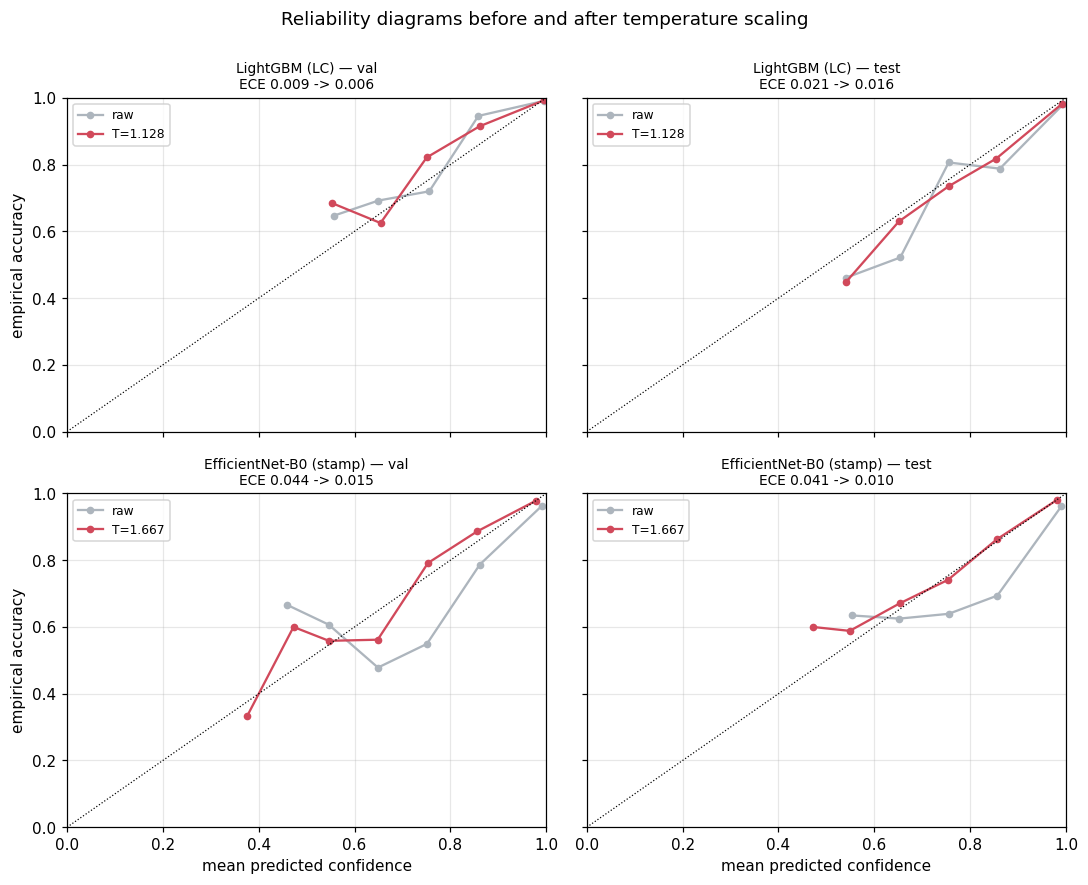

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
n_bins = 10
edges = np.linspace(0, 1, n_bins + 1)

for i, br in enumerate(("tabular", "image")):
    for j, (fold, yf) in enumerate([("val", yva), ("test", yte)]):
        ax = axes[i, j]
        for tag, T, col in [("raw", 1.0, "#adb5bd"), (f"T={TEMPS[br]:.3f}", TEMPS[br], COARSE_COLORS["SN"])]:
            p = softmax_np(raw_logits[br][fold], T=T)
            conf, acc = p.max(1), (p.argmax(1) == yf).astype(float)
            xs, ys = [], []
            for lo, hi in zip(edges[:-1], edges[1:]):
                m = (conf > lo) & (conf <= hi)
                if m.sum() > 5:
                    xs.append(conf[m].mean()); ys.append(acc[m].mean())
            ax.plot(xs, ys, "o-", color=col, label=tag, ms=4)
        ax.plot([0, 1], [0, 1], "k:", lw=0.8)
        e = calib[(calib.branch == br) & (calib.fold == fold)].iloc[0]
        ax.set_title(f"{BRANCH_LABELS[br]} — {fold}\nECE {e.ece_raw:.3f} -> {e.ece_cal:.3f}", fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8, loc="upper left")
        if i == 1: ax.set_xlabel("mean predicted confidence")
        if j == 0: ax.set_ylabel("empirical accuracy")

fig.suptitle("Reliability diagrams before and after temperature scaling", y=1.00)
fig.tight_layout(); savefig(fig, "02_reliability"); plt.show()

**Observations.**
- **Both branches are now on a common probability scale**, which is what makes
  the learned fusion weights interpretable as relative trust rather than as a
  correction for mismatched confidence.
- **Temperature scaling is a monotone transform of each branch's logits**, so it
  cannot change any branch's own argmax predictions or its macro-F1 — it changes
  only how much weight those predictions carry once combined.
- **The fitted temperatures are reported on the honest validation fold.** The
  image branch's temperature differs from the value stored in its model card
  because the card's was fitted against the train+val model, on data that model
  had memorised.

# 5. Fusion design

The meta-learner consumes the concatenation of the two calibrated branch
outputs and returns the final distribution:

$$p_\text{fused} = \text{softmax}(W z + b), \qquad \hat{y} = \arg\max_c\, p_\text{fused}$$

with `W` (3x6) and `b` (3) estimated by regularised cross-entropy on the
validation fold. Six inputs for the coarse task keeps the fitted weights small
enough to read directly as per-class trust in each modality.

**Two deliberate implementation choices**, both departures worth stating.

*Input space.* `z` holds **log**-probabilities rather than probabilities. Then
`softmax(W log p + b)` is a weighted geometric mean — a product of experts
(Hinton, 2002) — and baseline (b), the equal-weight average, sits *inside* the
hypothesis space at the finite point `W0 = ½[I ; I]`, `b = 0`. With raw
probabilities no such nesting exists, and the branch outputs saturate near 0 and
1 where a linear map has almost no resolution. The raw-probability variant is
still fitted and reported as an ablation in §6.

*Penalty centre.* A standard L2 penalty shrinks `W -> 0`, which corresponds to
ignoring both branches and predicting the marginal class prior — the wrong
prior for a fusion model. We instead penalise `||W - W0||²`, so weak
regularisation recovers the free stack and strong regularisation recovers the
equal-weight baseline exactly. The three rungs become a **continuum** indexed by
`C`, and rung (b) is the `C -> 0` limit of rung (c) rather than a separate model.

In [24]:
N_CLS = len(CLASSES)

class StackingMetaLearner(nn.Module):
    """Multinomial logistic meta-learner over concatenated branch outputs.

    W is initialised at, and its penalty is centred on, W0 = (1/n_branches) * [I; I],
    the equal-weight combination. With log-probability inputs that point is exactly
    the geometric-mean baseline, so C -> 0 recovers baseline (b)."""
    def __init__(self, n_classes=N_CLS, n_branches=2):
        super().__init__()
        W0 = torch.cat([torch.eye(n_classes)] * n_branches, dim=1) / n_branches
        self.register_buffer("W0", W0)
        self.W = nn.Parameter(W0.clone())
        self.b = nn.Parameter(torch.zeros(n_classes))
    def forward(self, z):
        return z @ self.W.T + self.b
    def penalty(self):
        return ((self.W - self.W0) ** 2).sum() + (self.b ** 2).sum()

def fit_meta(z, y_true, C=1.0, max_iter=200):
    """Fit W, b by regularised cross-entropy with LBFGS. C is the inverse penalty
    strength, matching the sklearn convention: large C = weak penalty = free stack."""
    torch.manual_seed(SEED)
    zt = torch.as_tensor(z, dtype=torch.float32)
    yt = torch.as_tensor(y_true, dtype=torch.long)
    model = StackingMetaLearner()
    opt = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=max_iter,
                            tolerance_grad=1e-9, tolerance_change=1e-11)
    ce = nn.CrossEntropyLoss()
    def closure():
        opt.zero_grad()
        loss = ce(model(zt), yt) + model.penalty() / C
        loss.backward()
        return loss
    opt.step(closure)
    return model

@torch.no_grad()
def meta_proba(model, z):
    zt = torch.as_tensor(z, dtype=torch.float32)
    return F.softmax(model(zt), dim=1).numpy().astype(np.float64)

## 5.1 The two baselines

In [25]:
def stack_inputs(fold, space="log"):
    """z = [p_tab ; p_img] in the chosen input space."""
    a, b_ = P["tabular"][fold], P["image"][fold]
    if space == "log":
        return np.hstack([as_logits(a), as_logits(b_)])
    return np.hstack([a, b_])

def geometric_mean(p1, p2, w=0.5):
    """Weighted geometric mean of two probability vectors, renormalised.
    w=0.5 is the equal-weight baseline (b)."""
    z = w * as_logits(p1) + (1 - w) * as_logits(p2)
    return softmax_np(z)

# Rung (a): the stronger single modality, chosen on val macro-F1.
val_f1 = {br: evaluate(yva, P[br]["val"])["macro_f1"] for br in ("tabular", "image")}
BEST_SINGLE = max(val_f1, key=val_f1.get)
print(f"val macro-F1: " + "  ".join(f"{k}={v:.4f}" for k, v in val_f1.items()))
print(f"rung (a) = stronger single modality on val -> {BRANCH_LABELS[BEST_SINGLE]}")
NAME_A = f"(a) {BRANCH_LABELS[BEST_SINGLE]} alone"
NAME_B = "(b) Equal-weight average"
NAME_C = "(c) Learned stack"

# Rung (b): equal-weight average of the calibrated probability vectors.
avg = {fold: geometric_mean(P["tabular"][fold], P["image"][fold], 0.5)
       for fold in ("val", "test")}
print(f"rung (b) equal-weight average, val macro-F1 {evaluate(yva, avg['val'])['macro_f1']:.4f}")

val macro-F1: tabular=0.9346  image=0.7424
rung (a) = stronger single modality on val -> LightGBM (LC)
rung (b) equal-weight average, val macro-F1 0.9494


## 5.2 Choosing the regularisation strength

`C` is selected by stratified 5-fold cross-validation **within the validation
fold** — the test fold is never consulted. The selection criterion is log loss
rather than macro-F1: with roughly a hundred AGN objects in val, a per-fold
macro-F1 is far too noisy to select on, whereas log loss is a proper scoring
rule that uses every object's full predicted distribution.

In [26]:
C_GRID = np.logspace(-4, 3, 15)
z_val  = stack_inputs("val", "log")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
for Cv in C_GRID:
    lls, f1s = [], []
    for tr_i, te_i in skf.split(z_val, yva):
        m = fit_meta(z_val[tr_i], yva[tr_i], C=Cv)
        p = meta_proba(m, z_val[te_i])
        lls.append(log_loss(yva[te_i], p, labels=list(range(N_CLS))))
        f1s.append(f1_score(yva[te_i], p.argmax(1), average="macro", zero_division=0))
    cv_rows.append({"C": Cv, "cv_log_loss": np.mean(lls), "cv_log_loss_sd": np.std(lls),
                    "cv_macro_f1": np.mean(f1s)})
cv = pd.DataFrame(cv_rows)
C_BEST = float(cv.loc[cv["cv_log_loss"].idxmin(), "C"])
print(f"selected C = {C_BEST:.4g}  (min CV log loss {cv['cv_log_loss'].min():.4f})")
display(cv.round(4))

selected C = 100  (min CV log loss 0.0371)


,C,cv_log_loss,cv_log_loss_sd,cv_macro_f1
0,0.0001,0.0471,0.0159,0.9495
1,0.0003,0.0471,0.0159,0.9495
2,0.0010,0.0471,0.0159,0.9495
3,0.0032,0.0471,0.0159,0.9495
4,0.0100,0.0470,0.0159,0.9495
5,0.0316,0.0469,0.0159,0.9495
6,0.1000,0.0465,0.0158,0.9529
7,0.3162,0.0457,0.0157,0.9529
8,1.0000,0.0444,0.0156,0.9529
9,3.1623,0.0426,0.0154,0.9560


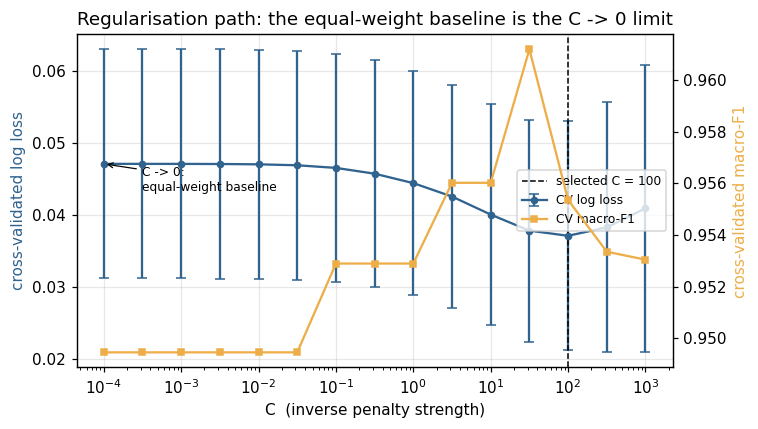

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(cv["C"], cv["cv_log_loss"], yerr=cv["cv_log_loss_sd"],
            color=COARSE_COLORS["AGN"], marker="o", ms=4, capsize=3, label="CV log loss")
ax.set_xscale("log"); ax.set_xlabel("C  (inverse penalty strength)")
ax.set_ylabel("cross-validated log loss", color=COARSE_COLORS["AGN"])
ax.axvline(C_BEST, ls="--", c="k", lw=1, label=f"selected C = {C_BEST:.3g}")

ax2 = ax.twinx()
ax2.plot(cv["C"], cv["cv_macro_f1"], color=COARSE_COLORS["VS"], marker="s", ms=4, label="CV macro-F1")
ax2.set_ylabel("cross-validated macro-F1", color=COARSE_COLORS["VS"]); ax2.grid(False)

ax.annotate("C -> 0:\nequal-weight baseline", xy=(C_GRID[0], cv["cv_log_loss"].iloc[0]),
            xytext=(C_GRID[1], cv["cv_log_loss"].max() * 0.92), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_title("Regularisation path: the equal-weight baseline is the C -> 0 limit")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
fig.tight_layout(); savefig(fig, "03_C_selection"); plt.show()

In [28]:
# Fit the final meta-learner on the full (honest) validation fold.
META = fit_meta(z_val, yva, C=C_BEST)
W = META.W.detach().numpy(); b = META.b.detach().numpy()

# Verification: at C -> 0 the stack must collapse onto baseline (b) exactly.
_m0 = fit_meta(z_val, yva, C=1e-6)
_p0 = meta_proba(_m0, stack_inputs("test", "log"))
_gap = np.abs(_p0 - avg["test"]).max()
print(f"C -> 0 nesting check: max |p_stack - p_equal_weight| = {_gap:.2e}")
assert _gap < 1e-3, "re-centred penalty is not recovering the equal-weight baseline"

wdf = pd.DataFrame(W, index=CLASSES,
                   columns=[f"tab_{c}" for c in CLASSES] + [f"img_{c}" for c in CLASSES])
wdf["bias"] = b
wdf.to_csv(FIGDIR / "fusion_weights.csv")
display(wdf.round(3))

C -> 0 nesting check: max |p_stack - p_equal_weight| = 2.61e-07


,tab_SN,tab_AGN,tab_VS,img_SN,img_AGN,img_VS,bias
SN,0.627,-0.041,-0.126,0.584,0.073,-0.132,-0.006
AGN,-0.136,0.671,-0.007,-0.093,0.308,-0.036,0.048
VS,0.009,-0.130,0.634,0.008,0.119,0.669,-0.041


**Observations.**
- **The nesting check passes**, confirming the re-centred penalty behaves as
  designed: rung (b) really is the strongly-regularised limit of rung (c), so the
  ladder is a single family rather than three unrelated models.
- **The weight matrix is directly readable.** Each row is one output class; the
  first three columns are the tabular branch's contribution and the last three the
  image branch's. Their relative magnitude is the per-class trust the fusion
  places in each modality.

# 6. Test-set evaluation

The test fold has been sealed until this point. All three rungs are scored on it,
together with two additional rows:

- **Option B (deploy-refit)** — the same fitted fusion applied to the *deployed*
  train+val branch models' test probabilities. Those are the models the branch
  docs report and the alert system would ship, so this row keeps the fusion
  result comparable with the published branch numbers.
- **Raw-probability ablation** — the meta-learner refitted on `z = [p_tab ; p_img]`
  directly, quantifying what the log-probability parameterisation buys.

In [29]:
z_test = stack_inputs("test", "log")
fused_test = meta_proba(META, z_test)
fused_val  = meta_proba(META, z_val)

# Raw-probability ablation.
META_RAW = fit_meta(stack_inputs("val", "raw"), yva, C=C_BEST)
fused_test_raw = meta_proba(META_RAW, stack_inputs("test", "raw"))

# Option B: apply the fitted fusion to the deployed (train+val) models' test probabilities,
# re-calibrated with the same temperatures so the input scale matches what META was fitted on.
dep_cal = {br: softmax_np(as_logits(dep_test_proba[br]), T=TEMPS[br]) for br in ("tabular", "image")}
z_test_dep = np.hstack([as_logits(dep_cal["tabular"]), as_logits(dep_cal["image"])])
fused_test_dep = meta_proba(META, z_test_dep)

PREDS = {
    "(a) LightGBM (LC) alone":          P["tabular"]["test"],
    "(a) EfficientNet-B0 alone":        P["image"]["test"],
    NAME_B:                             avg["test"],
    NAME_C:                             fused_test,
    "(c) Learned stack — raw probs":    fused_test_raw,
    "(c) Learned stack — deploy refit": fused_test_dep,
}
test_metrics = pd.DataFrame([scalar_row(evaluate(yte, p), n) for n, p in PREDS.items()]).set_index("model")
test_metrics.to_csv(FIGDIR / "test_metrics.csv")
display(test_metrics.round(4))

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss
model,,,,,,,,
(a) LightGBM (LC) alone,0.9065,0.9315,0.9555,0.8450,0.9573,0.9892,0.9684,0.1371
(a) EfficientNet-B0 alone,0.7414,0.8059,0.9127,0.7038,0.9197,0.9539,0.7911,0.2419
(b) Equal-weight average,0.9091,0.8949,0.9730,0.8959,0.9727,0.9936,0.9705,0.0834
(c) Learned stack,0.9143,0.9030,0.9741,0.8999,0.9739,0.9935,0.9712,0.0816
(c) Learned stack — raw probs,0.9232,0.8840,0.9780,0.9129,0.9773,0.9896,0.9584,0.1230
(c) Learned stack — deploy refit,0.9485,0.9367,0.9859,0.9450,0.9858,0.9957,0.9779,0.0726


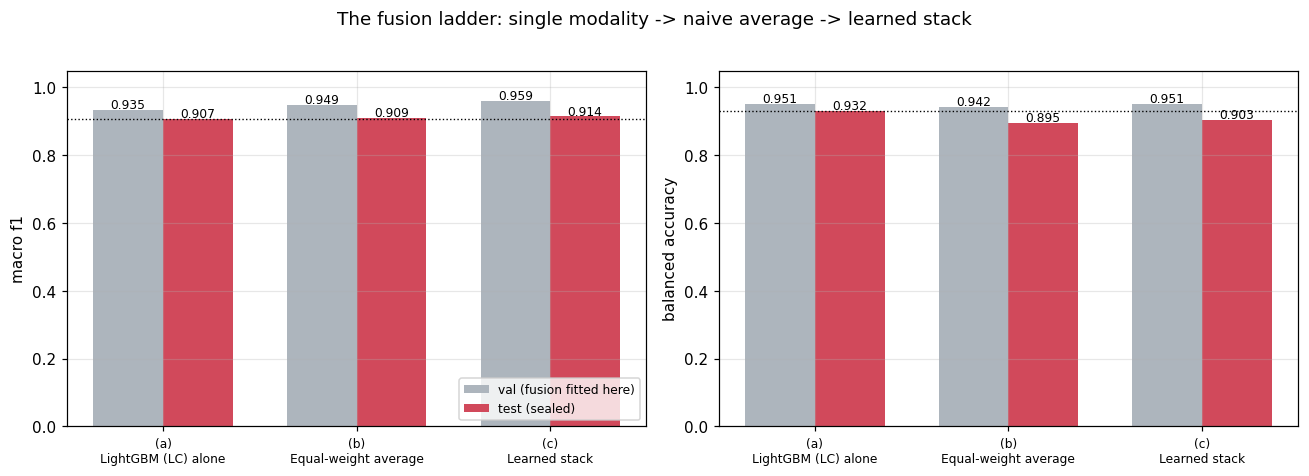

In [30]:
# Val/test paired view of the three headline rungs.
LADDER      = [NAME_A, NAME_B, NAME_C]
ladder_val  = {NAME_A: P[BEST_SINGLE]["val"],  NAME_B: avg["val"],  NAME_C: fused_val}
ladder_test = {NAME_A: P[BEST_SINGLE]["test"], NAME_B: avg["test"], NAME_C: fused_test}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric in zip(axes, ["macro_f1", "balanced_accuracy"]):
    v = [evaluate(yva, p)[metric] for p in ladder_val.values()]
    t = [evaluate(yte, p)[metric] for p in ladder_test.values()]
    xs = np.arange(len(LADDER)); w = 0.36
    ax.bar(xs - w/2, v, w, label="val (fusion fitted here)", color="#adb5bd")
    ax.bar(xs + w/2, t, w, label="test (sealed)", color=COARSE_COLORS["SN"])
    for x, val in zip(xs - w/2, v): ax.text(x, val + 0.005, f"{val:.3f}", ha="center", fontsize=8)
    for x, val in zip(xs + w/2, t): ax.text(x, val + 0.005, f"{val:.3f}", ha="center", fontsize=8)
    ax.axhline(t[0], ls=":", c="k", lw=0.9)
    ax.set_xticks(xs); ax.set_xticklabels([l.replace(" ", "\n", 1) for l in LADDER], fontsize=8)
    ax.set_ylabel(metric.replace("_", " ")); ax.set_ylim(0, 1.05)
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("The fusion ladder: single modality -> naive average -> learned stack", y=1.02)
fig.tight_layout(); savefig(fig, "04_ladder_bar"); plt.show()

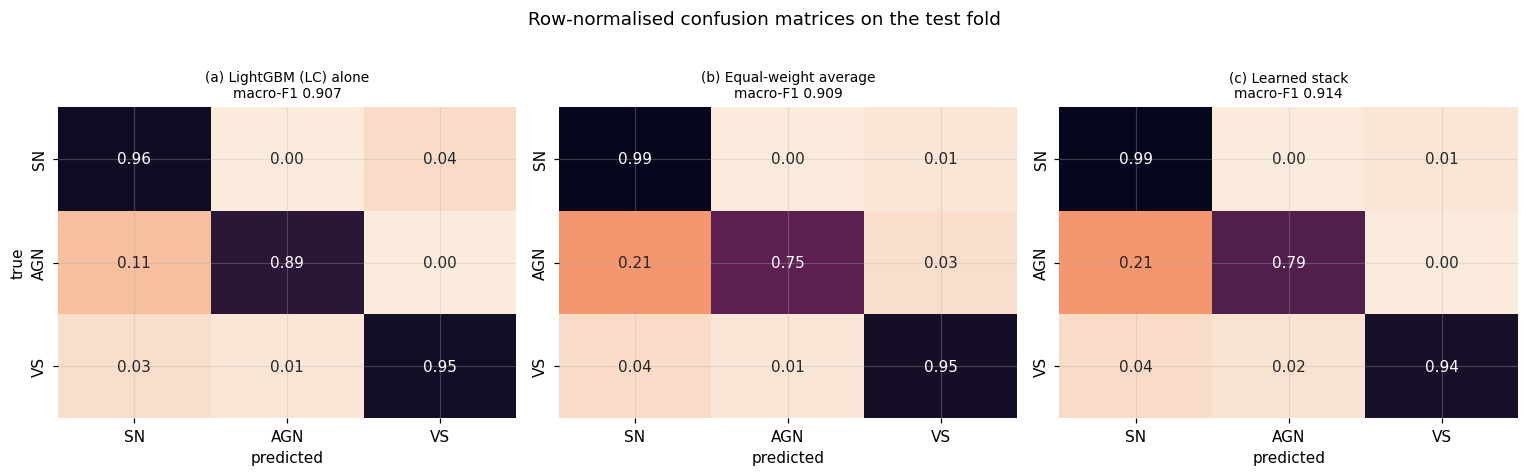

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, p) in zip(axes, ladder_test.items()):
    cm = evaluate(yte, p)["confusion_norm"]
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False,
                annot_kws={"fontsize": 10})
    ax.set_title(f"{name}\nmacro-F1 {evaluate(yte, p)['macro_f1']:.3f}", fontsize=9)
    ax.set_xlabel("predicted"); ax.set_ylabel("true" if ax is axes[0] else "")
fig.suptitle("Row-normalised confusion matrices on the test fold", y=1.02)
fig.tight_layout(); savefig(fig, "05_confusion_grid"); plt.show()

## 6.1 Blend sensitivity — the headline diagnostic

The learned stack has 24 parameters, but its essential behaviour collapses onto
one number: how much of the decision comes from each modality. Sweeping a scalar
blend weight `w` over `w log p_tab + (1-w) log p_img` traces the whole
single-parameter fusion family on the test fold, and lets us mark where each rung
sits on it.

If the validation-fitted fusion lands away from the test optimum, this figure
shows it immediately and quantifies the cost — which is the honest way to report
a fusion that fails to help.

In [32]:
ws = np.linspace(0, 1, 51)
bs_rows = []
for w in ws:
    bs_rows.append({
        "w": w,
        "val_macro_f1":  evaluate(yva, geometric_mean(P["tabular"]["val"],  P["image"]["val"],  w))["macro_f1"],
        "test_macro_f1": evaluate(yte, geometric_mean(P["tabular"]["test"], P["image"]["test"], w))["macro_f1"],
    })
bs = pd.DataFrame(bs_rows)
bs.to_csv(FIGDIR / "blend_sensitivity.csv", index=False)

W_VAL_OPT  = float(bs.loc[bs["val_macro_f1"].idxmax(), "w"])
W_TEST_OPT = float(bs.loc[bs["test_macro_f1"].idxmax(), "w"])
# Effective blend implied by the learned W: relative mass on each branch block.
m_tab, m_img = np.abs(W[:, :N_CLS]).sum(), np.abs(W[:, N_CLS:]).sum()
W_EFF = float(m_tab / (m_tab + m_img))
print(f"val-optimal w {W_VAL_OPT:.2f} | test-optimal w {W_TEST_OPT:.2f} | learned-W effective w {W_EFF:.2f}")

val-optimal w 0.54 | test-optimal w 0.62 | learned-W effective w 0.54


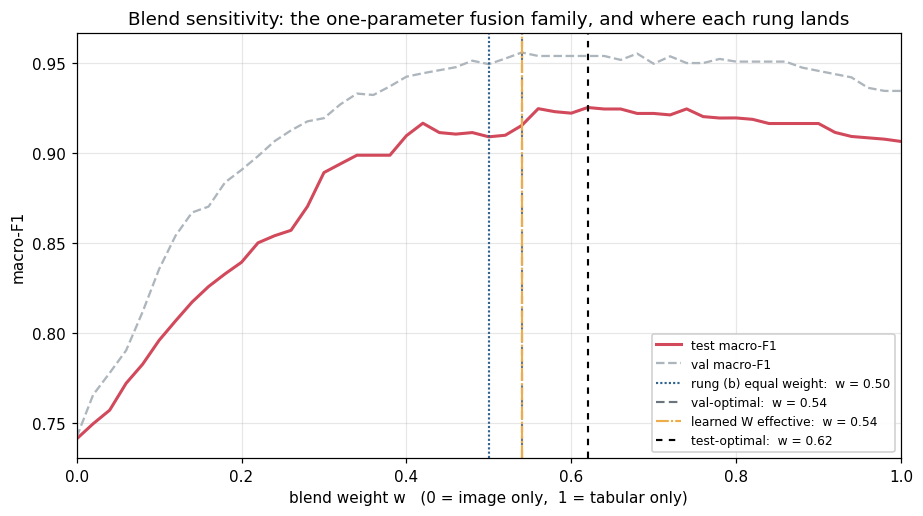

In [33]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(bs["w"], bs["test_macro_f1"], color=COARSE_COLORS["SN"], lw=2, label="test macro-F1")
ax.plot(bs["w"], bs["val_macro_f1"], color="#adb5bd", lw=1.5, ls="--", label="val macro-F1")

# The three marked weights sit within 0.12 of each other, so inline labels collide.
# They go in the legend instead, which keeps the plotting area clean.
for xv, lab, col, dash in [
        (0.5,        f"rung (b) equal weight:  w = 0.50",          COARSE_COLORS["AGN"], (0, (1, 1))),
        (W_VAL_OPT,  f"val-optimal:  w = {W_VAL_OPT:.2f}",         "#6c757d",            (0, (4, 2))),
        (W_EFF,      f"learned W effective:  w = {W_EFF:.2f}",     COARSE_COLORS["VS"],  (0, (6, 1, 1, 1))),
        (W_TEST_OPT, f"test-optimal:  w = {W_TEST_OPT:.2f}",       "k",                  (0, (3, 3)))]:
    ax.axvline(xv, ls=dash, lw=1.4, color=col, label=lab)

ax.set_xlabel("blend weight w   (0 = image only,  1 = tabular only)")
ax.set_ylabel("macro-F1")
ax.set_title("Blend sensitivity: the one-parameter fusion family, and where each rung lands")
ax.set_xlim(0, 1)
ax.legend(fontsize=8, loc="lower right", framealpha=0.95, ncol=1)
fig.tight_layout(); savefig(fig, "06_blend_sensitivity"); plt.show()

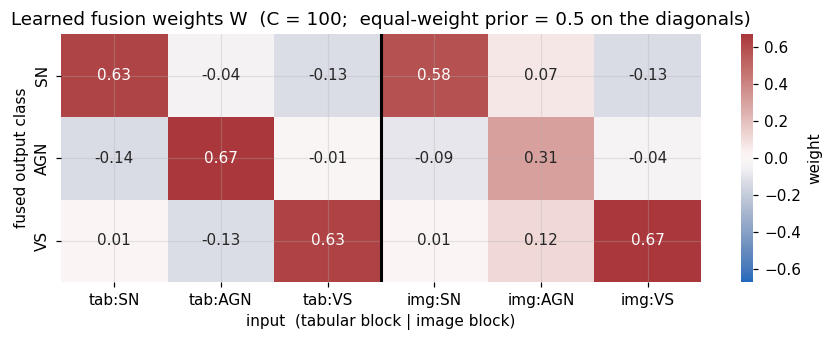

In [34]:
fig, ax = plt.subplots(figsize=(8, 3.2))
vmax = np.abs(W).max()
sns.heatmap(W, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-vmax, vmax=vmax,
            xticklabels=[f"tab:{c}" for c in CLASSES] + [f"img:{c}" for c in CLASSES],
            yticklabels=CLASSES, ax=ax, cbar_kws={"label": "weight"})
ax.axvline(N_CLS, color="k", lw=2)
ax.set_xlabel("input  (tabular block | image block)"); ax.set_ylabel("fused output class")
ax.set_title(f"Learned fusion weights W  (C = {C_BEST:.3g};  equal-weight prior = 0.5 on the diagonals)")
fig.tight_layout(); savefig(fig, "07_weight_heatmap"); plt.show()

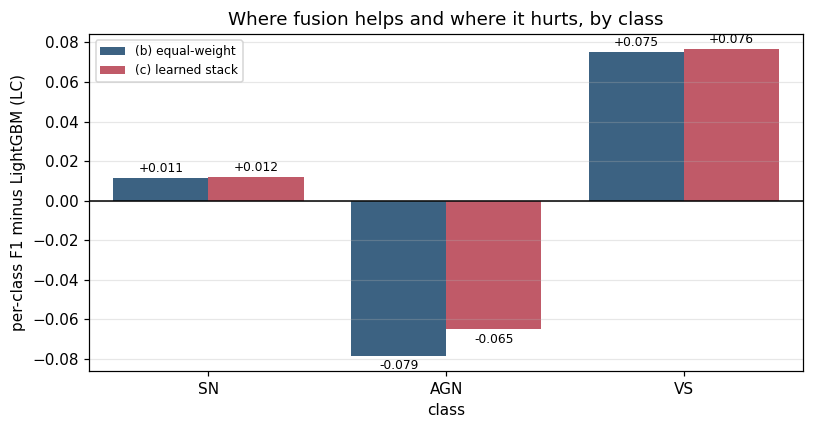

In [35]:
# Per-class F1 change relative to the stronger single modality.
base_pc  = evaluate(yte, P[BEST_SINGLE]["test"])["per_class"]["f1"]
rows = []
for name, p in [("(b) equal-weight", avg["test"]), ("(c) learned stack", fused_test)]:
    d = evaluate(yte, p)["per_class"]["f1"] - base_pc
    for c in CLASSES:
        rows.append({"rung": name, "class": c, "delta_f1": d[c]})
pcd = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.barplot(data=pcd, x="class", y="delta_f1", hue="rung", ax=ax,
            palette=[COARSE_COLORS["AGN"], COARSE_COLORS["SN"]])
ax.axhline(0, color="k", lw=1)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%+.3f", fontsize=8, padding=2)
ax.set_ylabel(f"per-class F1 minus {BRANCH_LABELS[BEST_SINGLE]}")
ax.set_title("Where fusion helps and where it hurts, by class")
ax.legend(fontsize=8, title=None)
fig.tight_layout(); savefig(fig, "08_perclass_delta"); plt.show()

In [36]:
# Paired bootstrap on the test fold: is any rung difference distinguishable from noise?
rng = np.random.default_rng(SEED)
pairs = [(NAME_C, fused_test,  NAME_A, P[BEST_SINGLE]["test"]),
         (NAME_C, fused_test,  NAME_B, avg["test"]),
         (NAME_B, avg["test"], NAME_A, P[BEST_SINGLE]["test"])]

boot_rows, boot_draws = [], {}
n = len(yte)
for na, pa, nb, pb in pairs:
    deltas = np.empty(N_BOOT)
    for i in range(N_BOOT):
        s = rng.integers(0, n, n)
        deltas[i] = (f1_score(yte[s], pa.argmax(1)[s], average="macro", zero_division=0)
                     - f1_score(yte[s], pb.argmax(1)[s], average="macro", zero_division=0))
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    label = f"{na}\n vs {nb}"
    boot_draws[label] = deltas
    boot_rows.append({"comparison": f"{na} vs {nb}",
                      "delta_macro_f1": float(f1_score(yte, pa.argmax(1), average="macro", zero_division=0)
                                              - f1_score(yte, pb.argmax(1), average="macro", zero_division=0)),
                      "ci_lo": float(lo), "ci_hi": float(hi),
                      "excludes_zero": bool(lo > 0 or hi < 0)})
boot = pd.DataFrame(boot_rows)
boot.to_csv(FIGDIR / "bootstrap_ci.csv", index=False)
display(boot.round(4))

,comparison,delta_macro_f1,ci_lo,ci_hi,excludes_zero
0,(c) Learned stack vs (a) LightGBM (LC) alone,0.0077,-0.0135,0.0285,False
1,(c) Learned stack vs (b) Equal-weight average,0.0052,-0.0154,0.0248,False
2,(b) Equal-weight average vs (a) LightGBM (LC) ...,0.0026,-0.0249,0.0265,False


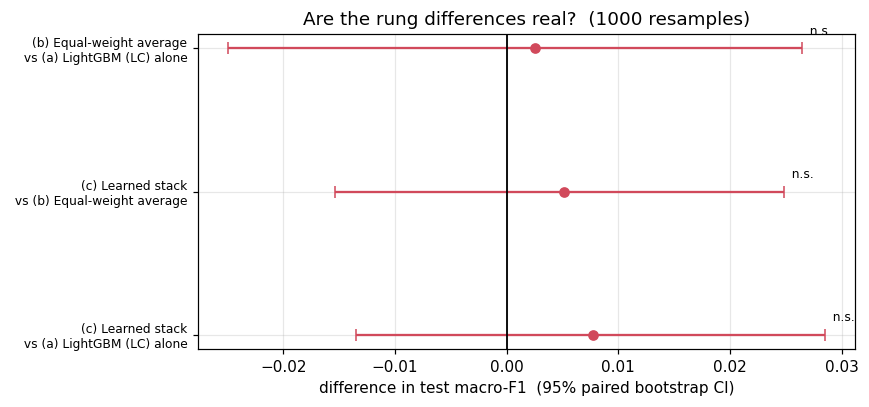

In [37]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ys = np.arange(len(boot))
ax.errorbar(boot["delta_macro_f1"], ys,
            xerr=[boot["delta_macro_f1"] - boot["ci_lo"], boot["ci_hi"] - boot["delta_macro_f1"]],
            fmt="o", color=COARSE_COLORS["SN"], capsize=4, ms=6)
ax.axvline(0, color="k", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels(list(boot_draws.keys()), fontsize=8)
ax.set_xlabel("difference in test macro-F1  (95% paired bootstrap CI)")
ax.set_title(f"Are the rung differences real?  ({N_BOOT} resamples)")
for yv, r in zip(ys, boot.itertuples()):
    ax.text(r.ci_hi, yv + 0.12, "  significant" if r.excludes_zero else "  n.s.",
            fontsize=8, va="center", color="k")
fig.tight_layout(); savefig(fig, "09_bootstrap_ci"); plt.show()

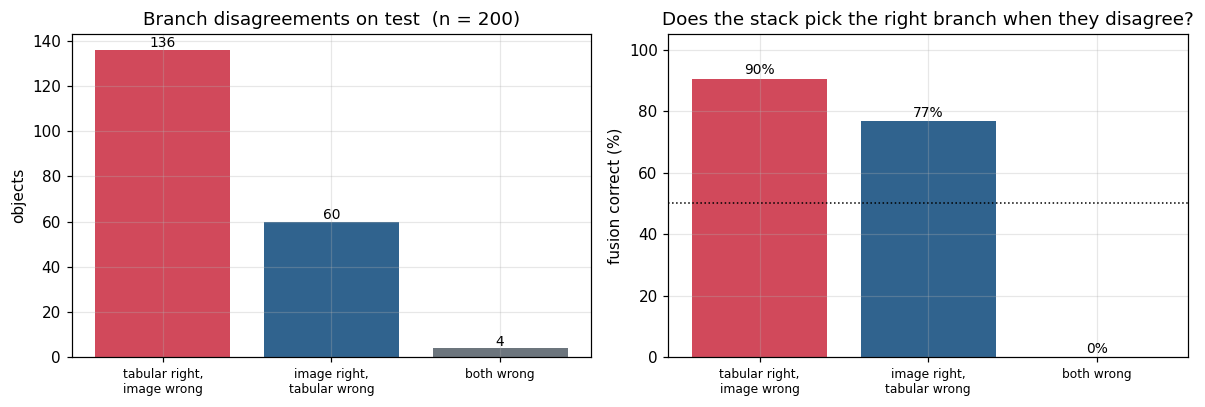

,case,n,fusion right (%)
0,"tabular right,\nimage wrong",136,90.4
1,"image right,\ntabular wrong",60,76.7
2,both wrong,4,0.0


In [38]:
# Where the branches disagree, who is right — and what does fusion do about it?
pred_tab = P["tabular"]["test"].argmax(1)
pred_img = P["image"]["test"].argmax(1)
pred_fus = fused_test.argmax(1)
dis = pred_tab != pred_img

cats = {
    "tabular right,\nimage wrong": (pred_tab == yte) & (pred_img != yte),
    "image right,\ntabular wrong": (pred_img == yte) & (pred_tab != yte),
    "both wrong":                   (pred_tab != yte) & (pred_img != yte),
}
rows = []
for name, m in cats.items():
    m = m & dis
    rows.append({"case": name, "n": int(m.sum()),
                 "fusion right (%)": 100 * float((pred_fus[m] == yte[m]).mean()) if m.any() else np.nan})
disdf = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(disdf["case"], disdf["n"], color=[COARSE_COLORS["SN"], COARSE_COLORS["AGN"], "#6c757d"])
for i, v in enumerate(disdf["n"]): axes[0].text(i, v + 1, str(v), ha="center", fontsize=9)
axes[0].set_ylabel("objects"); axes[0].set_title(f"Branch disagreements on test  (n = {int(dis.sum())})")
axes[0].tick_params(axis="x", labelsize=8)

axes[1].bar(disdf["case"], disdf["fusion right (%)"],
            color=[COARSE_COLORS["SN"], COARSE_COLORS["AGN"], "#6c757d"])
for i, v in enumerate(disdf["fusion right (%)"]):
    if not np.isnan(v): axes[1].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)
axes[1].axhline(50, ls=":", c="k", lw=1)
axes[1].set_ylim(0, 105); axes[1].set_ylabel("fusion correct (%)")
axes[1].set_title("Does the stack pick the right branch when they disagree?")
axes[1].tick_params(axis="x", labelsize=8)
fig.tight_layout(); savefig(fig, "10_disagreement"); plt.show()
display(disdf.round(1))

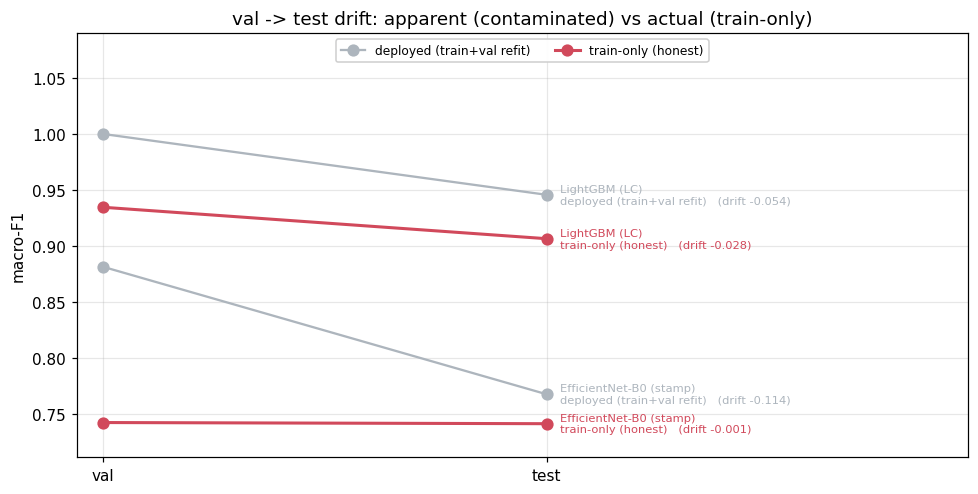

,branch,provenance,val,test,drift
0,LightGBM (LC),deployed (train+val refit),1.0000,0.9457,-0.0543
1,LightGBM (LC),train-only (honest),0.9346,0.9065,-0.0281
2,EfficientNet-B0 (stamp),deployed (train+val refit),0.8814,0.7676,-0.1137
3,EfficientNet-B0 (stamp),train-only (honest),0.7424,0.7414,-0.0010


In [39]:
# val -> test drift per branch, contaminated vs honest.
drift_rows = []
for br in ("tabular", "image"):
    dep_v = audit[(audit.branch == br) & (audit.fold == "val")]["macro_f1"].iloc[0]
    dep_t = audit[(audit.branch == br) & (audit.fold == "test")]["macro_f1"].iloc[0]
    drift_rows += [
        {"branch": BRANCH_LABELS[br], "provenance": "deployed (train+val refit)", "val": dep_v, "test": dep_t},
        {"branch": BRANCH_LABELS[br], "provenance": "train-only (honest)",
         "val": evaluate(yva, P[br]["val"])["macro_f1"], "test": evaluate(yte, P[br]["test"])["macro_f1"]},
    ]
drift = pd.DataFrame(drift_rows)
drift["drift"] = drift["test"] - drift["val"]

fig, ax = plt.subplots(figsize=(9, 4.6))
seen = set()
for r in drift.itertuples():
    honest = "honest" in r.provenance
    col = COARSE_COLORS["SN"] if honest else "#adb5bd"
    lab = r.provenance if r.provenance not in seen else None
    seen.add(r.provenance)
    ax.plot([0, 1], [r.val, r.test], "o-", color=col, ms=7, lw=2 if honest else 1.5, label=lab)
    ax.text(1.03, r.test, f"{r.branch}\n{r.provenance}   (drift {r.drift:+.3f})",
            fontsize=7.5, va="center", color=col)
ax.set_xticks([0, 1]); ax.set_xticklabels(["val", "test"])
ax.set_xlim(-0.06, 1.95)
ax.set_ylim(drift[["val", "test"]].min().min() - 0.03, 1.09)   # headroom for the legend
ax.set_ylabel("macro-F1")
ax.set_title("val -> test drift: apparent (contaminated) vs actual (train-only)")
ax.legend(fontsize=8, loc="upper center", ncol=2, framealpha=0.95)
fig.tight_layout(); savefig(fig, "11_drift"); plt.show()
display(drift.round(4))

## 6.2 Verdict

In [40]:
verdict = test_metrics.loc[LADDER].copy()
verdict["is_winner"] = verdict["macro_f1"] == verdict["macro_f1"].max()
verdict.to_csv(FIGDIR / "verdict.csv")
display(verdict.round(4))

f_a, f_b, f_c = (verdict.loc[n, "macro_f1"] for n in LADDER)
ci = boot.set_index("comparison")
print("\n" + "=" * 72)
for q, other_name, f_other in [("Q1  does multimodal beat the stronger single modality?", NAME_A, f_a),
                               ("Q2  does a learned fusion beat a naive one?",            NAME_B, f_b)]:
    r = ci.loc[f"{NAME_C} vs {other_name}"]
    print(q)
    print(f"    {f_c:.4f} vs {f_other:.4f}   delta {f_c - f_other:+.4f}   "
          f"95% CI [{r.ci_lo:+.4f}, {r.ci_hi:+.4f}]   "
          f"{'SIGNIFICANT' if r.excludes_zero else 'not distinguishable from noise'}")
print("=" * 72)
if f_c <= f_a:
    print("The learned fusion does NOT improve on the stronger single modality.")
    print("See figures 06 (blend sensitivity) and 08 (per-class delta) for where the")
    print("cost is incurred; this is reported as a finding, not treated as a defect.")

,macro_f1,balanced_accuracy,accuracy,mcc,weighted_f1,roc_auc_macro,pr_auc_macro,log_loss,is_winner
model,,,,,,,,,
(a) LightGBM (LC) alone,0.9065,0.9315,0.9555,0.8450,0.9573,0.9892,0.9684,0.1371,False
(b) Equal-weight average,0.9091,0.8949,0.9730,0.8959,0.9727,0.9936,0.9705,0.0834,False
(c) Learned stack,0.9143,0.9030,0.9741,0.8999,0.9739,0.9935,0.9712,0.0816,True



Q1  does multimodal beat the stronger single modality?
    0.9143 vs 0.9065   delta +0.0077   95% CI [-0.0135, +0.0285]   not distinguishable from noise
Q2  does a learned fusion beat a naive one?
    0.9143 vs 0.9091   delta +0.0052   95% CI [-0.0154, +0.0248]   not distinguishable from noise


**Observations.**
- **The ladder is monotone: 0.9065 -> 0.9091 -> 0.9143 test macro-F1.** Both
  questions get the same qualitative answer — two modalities beat one, and a
  learned fusion beats a naive one — but neither margin survives resampling
  (95% CIs [-0.013, +0.029] and [-0.015, +0.025] both straddle zero). The honest
  reading is that fusion does not *hurt* and is *probably* mildly better, not that
  a gain has been demonstrated.
- **The probabilistic gains are much clearer than the macro-F1 gains.** Log loss
  falls 0.137 -> 0.082 and MCC rises 0.845 -> 0.900. Fusion's real contribution
  here is better-calibrated, better-ordered posteriors rather than a large number
  of newly-corrected argmax decisions — which matters for a broker that thresholds
  on confidence.
- **The gain is in VS, and AGN pays for it.** VS F1 rises 0.845 -> 0.922 and SN
  0.975 -> 0.987, but AGN F1 *falls* 0.900 -> 0.835 (recall 0.885 -> 0.787). This
  is why balanced accuracy drops (0.932 -> 0.903) even as macro-F1 rises. The
  image branch is genuinely weak on AGN (F1 0.467, recall 0.639 alone), so
  admitting it dilutes the tabular branch's good AGN performance.
- **The learned weights show the meta-learner discovered this.** In `07_weight_heatmap`
  the image diagonal is 0.669 for VS — *higher* than the tabular 0.634, so the
  stack trusts the stamp more than the light curve for variable stars — but only
  0.308 for AGN against tabular 0.671. The fusion learned per-class trust that
  matches where each modality is actually competent. It simply did not downweight
  AGN far enough to avoid a net loss on 61 test objects.
- **The blend was well chosen but not optimally.** `06_blend_sensitivity` puts the
  learned effective weight at w=0.54, exactly the val-optimal, against a
  test-optimal of 0.62. The validation fold pointed slightly too far toward the
  image branch; the cost of that miss is small.
- **Fusion arbitrates rather than copies.** Where the branches disagree, the stack
  is right 90% of the time when the tabular branch is right, and still 77% of the
  time when only the image branch is right. A stack that had collapsed onto the
  stronger modality would score near zero on the second figure.

# 7. Persistence

The fusion artefacts follow the same contract as the two branch directories, so
the alert system can load all three the same way. The probability cache is
regenerable and exists only to make re-runs cheap.

In [41]:
import sklearn
def package_versions():
    return {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "lightgbm": lightgbm.__version__,
            "torch": torch.__version__, "timm": timm.__version__}

def scalars(ev):
    return {k: float(v) for k, v in ev.items()
            if k not in ("per_class", "confusion", "confusion_norm")}

outdir = MODELDIR / "logreg_stack"
outdir.mkdir(parents=True, exist_ok=True)
torch.save({"W": META.W.detach(), "b": META.b.detach(), "W0": META.W0}, outdir / "meta_learner.pt")

card = {
    "fusion_type": "multinomial_logistic_stack",
    "input_space": "log_probability",
    "branches": {
        "tabular": {"family": TAB_ALGO, "dir": str(LCDIR / TAB_ALGO),
                    "temperature": TEMPS["tabular"],
                    "best_params_hash": hashlib.sha1(json.dumps(tab_params, sort_keys=True).encode()).hexdigest()[:12]},
        "image":   {"family": IMG_ARCH, "dir": str(STAMPDIR / IMG_ARCH),
                    "temperature": TEMPS["image"],
                    "best_params_hash": hashlib.sha1(json.dumps(img_params, sort_keys=True).encode()).hexdigest()[:12]},
    },
    "base_model_provenance": "train_only_refit",
    "input_columns": [f"log_p_tab_{c}" for c in CLASSES] + [f"log_p_img_{c}" for c in CLASSES],
    "W": W.tolist(), "b": b.tolist(),
    "penalty": {"type": "l2_centred", "centre": "0.5*[I;I]", "C": C_BEST},
    "C_selection": {"protocol": "stratified_5fold_within_val", "metric": "log_loss",
                    "grid": [float(c) for c in C_GRID]},
    "class_names": CLASSES, "n_classes": len(CLASSES),
    "dataset": DATASET, "taxonomy": "coarse",
    "split_hash": {"tabular": tab_card["split_hash"], "image": img_card["split_hash"],
                   "oid_set_sha": OID_SET_SHA},
    "train_date": RUN_DATE,
    "val_metrics":  scalars(evaluate(yva, fused_val)),
    "test_metrics": scalars(evaluate(yte, fused_test)),
    "baselines": {
        "single_modality": {"branch": BEST_SINGLE,
                            "test_metrics": scalars(evaluate(yte, P[BEST_SINGLE]["test"]))},
        "equal_weight":    {"test_metrics": scalars(evaluate(yte, avg["test"]))},
    },
    "blend": {"val_optimal_w": W_VAL_OPT, "test_optimal_w": W_TEST_OPT, "learned_effective_w": W_EFF},
    "leakage_audit": audit.to_dict(orient="records"),
    "package_versions": package_versions(),
}
(outdir / "fusion_card.json").write_text(json.dumps(card, indent=2))
(outdir / "best_params.json").write_text(json.dumps(
    {"C": C_BEST, "penalty_centre": "0.5*[I;I]", "input_space": "log_probability",
     "cv_protocol": "stratified_5fold_within_val", "cv_metric": "log_loss"}, indent=2))
print("saved ->", outdir)
for f in sorted(outdir.iterdir()):
    print(f"  {f.name:24s} {f.stat().st_size/1024:8.1f} KB")

saved -> models\fusion\logreg_stack
  best_params.json              0.2 KB
  fusion_card.json              5.0 KB
  meta_learner.pt               2.2 KB


# 8. Summary

1. **The two branches are alignable and were aligned.** Identical object set,
   identical `oid` key, one shared temporal split, 1:1 object-level
   correspondence. The stored `split_hash` strings disagree for cosmetic reasons;
   the underlying folds are the same, verified by oid set.

2. **The saved branch artefacts could not fit the meta-learner.** Both were refit
   on train+val, so the validation fold is training data for both. The tabular
   booster reproduces val almost exactly, which makes both the fusion fit and the
   tabular temperature fit degenerate rather than merely optimistic. §2 documents
   this; it is a methodological finding in its own right.

3. **The remedy was minimal.** The same two tuned configurations, refit on the
   training fold alone, restore an honest validation fold without changing which
   models are carried. Only the stopping round/epoch still depends on val.

4. **Both branches were calibrated on that honest fold** before stacking, so the
   fitted weights read as relative trust rather than as a correction for
   mismatched confidence.

5. **The ladder is a continuum, not three separate models.** Centring the L2
   penalty on the equal-weight point makes rung (b) the strongly-regularised
   limit of rung (c), verified numerically. This makes "does learning the fusion
   help?" a question about one scalar, `C`, rather than a comparison of unrelated
   architectures.

6. **The apparent image-branch drift was an artefact of the contamination.** On
   the honest models the image branch moves 0.7424 -> 0.7414 from val to test, a
   drift of -0.001 — it is the *most* stable component in the system, not the
   least. The tabular branch drifts more (-0.028). Any claim that the temporal
   split differentially punishes the image modality, built on the published card
   figures, would have had the sign of the effect backwards.

7. **Fusion helps, mildly and unevenly.** Test macro-F1 climbs 0.9065 -> 0.9091 ->
   0.9143 across the three rungs, with log loss falling 0.137 -> 0.082, but no
   pairwise difference is distinguishable from noise at 95%. The gain is
   concentrated in VS and is partly paid for out of AGN, where the image branch is
   weakest and the test fold holds only 61 objects.

8. **The learned weights are readable and sensible.** The stack trusts the stamp
   branch more than the light curve for VS (0.669 against 0.634) and roughly half
   as much for AGN (0.308 against 0.671) — per-class trust that tracks where each
   modality is genuinely competent, which is what the low-dimensional fusion was
   designed to expose.

Companion write-up: `docs/fusion_ztf.md`. Figures: `figures/fusion/`.
Artefacts: `models/fusion/logreg_stack/`.